# MULTIVARIATE REGRESSION, DATA MANIPULATION, and ANALYSIS

## Gather all gage characteristics I will be using for the multivariable regression

In [1]:
# Load a
import sys
import os as os

import geopandas as gpd
import numpy as np
from numpy.polynomial import Polynomial
import psycopg2
from netCDF4 import Dataset

from tqdm import tqdm
from multiprocessing import Pool
import statsmodels.api as sm
from scipy import stats
# from scipy import optimize

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature as cfNEF

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patches
#import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D

import rasterio
import xarray as xr

import random
import subprocess
import netCDF4 as nc
import shutil

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ShuffleSplit
import seaborn as sns
from scipy.stats import gaussian_kde

import pathlib
import glob
import pandas as pd

from sklearn.metrics import r2_score
from scipy.stats import normaltest

import geopandas as gpd
import xarray as xr
from rasterio import features
from shapely.geometry import mapping
import rioxarray
import scipy


import geopandas as gpd
import rioxarray
from shapely.geometry import mapping
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.dates as mdates

### Load all shapefiles from the 3 assimilations and concatinate into one

In [ ]:
# Load shapefile that contains stations and delta SWE from the January 10th assimilation
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\umrb_deltas_2024\UMRB_2024_deltas_formatted.shp"

# Load shapefile
UMRB_stations_all_dates = gpd.read_file(shapefile_path)

# Just keep the columns Latitude, Longitude, Station_id, station_ty, station_elevation, DEM_elevation, Forest_den, D_SWE_OM
# Keep only the specified columns
columns_to_keep = ['LATITUDE', 'LONGITUDE', 'STATION_ID', 'STATION_TY', 'STATION_EL', 'DEM_ELEVAT', 'MD_DEPTH_T','D_SWE_OM', 'OB_SWE', 'MD_SWE' ]

UMRB_stations_all_dates = UMRB_stations_all_dates[columns_to_keep]

print(UMRB_stations_all_dates)

In [ ]:
# Load shapefile that contains stations and delta SWE from the January 10th assimilation
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_20240110_with_umrb\ssm1054_md_based_2024010912_2024011012_central.shp"

# Load shapefile
Jan_10_2024_stations = gpd.read_file(shapefile_path)

# Drop all points that arent stations
Jan_10_2024_stations = Jan_10_2024_stations[Jan_10_2024_stations['VALUE'] != 1]

# Just keep the columns Latitude, Longitude, Station_id, station_ty, station_elevation, DEM_elevation, Forest_den, D_SWE_OM
# Keep only the specified columns
columns_to_keep = ['LATITUDE', 'LONGITUDE', 'STATION_ID', 'STATION_TY', 'STATION_EL', 'DEM_ELEVAT', 'FOREST_DEN', 'MD_DEPTH_T','D_SWE_OM', 'OB_SWE', 'MD_SWE' ]

Jan_10_2024_stations = Jan_10_2024_stations[columns_to_keep]

print(Jan_10_2024_stations)

In [ ]:
# Load shapefile that contains stations and delta SWE from the 12/11/22 assimilation
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_with_umrb\ssm1054_md_based_2022121012_2022121112_east.shp"

# Load shapefile
Dec_11_2022_stations = gpd.read_file(shapefile_path)

# Drop all points that arent stations
Dec_11_2022_stations = Dec_11_2022_stations[Dec_11_2022_stations['VALUE'] != 1]

# Just keep the columns Latitude, Longitude, Station_id, station_ty, station_elevation, DEM_elevation, Forest_den, D_SWE_OM
# Keep only the specified columns
columns_to_keep = ['LATITUDE', 'LONGITUDE', 'STATION_ID', 'STATION_TY', 'STATION_EL', 'DEM_ELEVAT', 'FOREST_DEN','MD_DEPTH_T', 'D_SWE_OM', 'OB_SWE', 'MD_SWE']

Dec_11_2022_stations = Dec_11_2022_stations[columns_to_keep]

print(Dec_11_2022_stations)

In [ ]:
# Load shapefile that contains stations and delta SWE from the 12/28/23 assimilation
shapefile_path = r"C:\Repos\umrb-snodas\Test_Runs\snodas_assim_20231228_with_umrb_updated_base\ssm1054_md_based_2023122712_2023122812_central.shp"

# Load shapefile
Dec_28_2023_stations = gpd.read_file(shapefile_path)

# Drop all points that arent stations
Dec_28_2023_stations  = Dec_28_2023_stations [Dec_28_2023_stations ['VALUE'] != 1]

# Just keep the columns Latitude, Longitude, Station_id, station_ty, station_elevation, DEM_elevation, Forest_den, D_SWE_OM
# Keep only the specified columns
columns_to_keep = ['LATITUDE', 'LONGITUDE', 'STATION_ID', 'STATION_TY', 'STATION_EL', 'DEM_ELEVAT', 'FOREST_DEN', 'MD_DEPTH_T','D_SWE_OM', 'OB_SWE', 'MD_SWE']

Dec_28_2023_stations  = Dec_28_2023_stations [columns_to_keep]

print(Dec_28_2023_stations )

In [4]:
# Read the UMRB Station attribute text file
umrb_station_attributes = pd.read_csv(
    r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\umrb_meta_20240425.txt',
    delimiter='|',
    header=None,
    engine='python'
)

# Keep only the first 8 columns
umrb_station_attributes = umrb_station_attributes.iloc[:, :8]

# Rename the columns
umrb_station_attributes.columns = ['STATION_ID', 'LOCATION', 'UNKNOWN', 'STATION_TY', 'LATITUDE', 'LONGITUDE', 'STATION_EL', 'DEM_ELEVAT']

# Remove any leading/trailing spaces in the STATION_ID column
umrb_station_attributes['STATION_ID'] = umrb_station_attributes['STATION_ID'].str.strip()

umrb_station_attributes

,STATION_ID,LOCATION,UNKNOWN,STATION_TY,LATITUDE,LONGITUDE,STATION_EL,DEM_ELEVAT
0,FRGM8,FORESTGROVE N,TFX,MESO-UMRB,47.1057,-109.0888,1243,1251
1,PLMW4,POWELL 2SW - WY MESONET,RIW,MESO-ST,44.7764,-108.7590,1333,1333
2,AIDN8,AMIDON NDAWN,BIS,MESO-ST,46.4880,-103.3160,875,878
3,RAYN8,RAY 4N NDAWN,BIS,MESO-ST,48.4009,-103.1692,702,706
4,BOMN8,BOWMAN NDAWN,BIS,MESO-ST,46.2000,-103.4730,910,924
...,...,...,...,...,...,...,...,...
107,WIEM8,WINNETT 7SW,GGW,MESO-UMRB,46.9653,-108.5024,975,976
108,WRHM8,WAR HORSE NW,GGW,MESO-UMRB,47.1472,-108.5913,958,960
109,DOOM8,DOOLEY NDAWN,GGW,MESO-ST,48.8336,-104.3845,783,783
110,RSTM8,REDSTONE NDAWN,GGW,MESO-ST,48.8245,-104.8417,729,732


### Add windspeed into attribute dataframe

In [ ]:
# Upload 2024 wind speed data

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\vs_2024.nc"

#read in the file with xarray:
wind_speed_2024 = xr.open_dataset(file_path)

wind_speed_2024 = wind_speed_2024.compute()

wind_speed_2024

In [ ]:
# Upload 2022 wind speed data

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\vs_2022.nc"

#read in the file with xarray:
wind_speed_2022 = xr.open_dataset(file_path)

wind_speed_2022 = wind_speed_2022.compute()

wind_speed_2022

In [ ]:
# Upload 2023 wind speed data

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\vs_2023.nc"

#read in the file with xarray:
wind_speed_2023 = xr.open_dataset(file_path)

wind_speed_2023 = wind_speed_2023.compute()

wind_speed_2023

In [ ]:
# Merge datasets along the time dimension
merged_wind_speed = xr.concat([wind_speed_2023,wind_speed_2024], dim='day')

# Optionally, you may want to sort the dataset by the 'day' dimension
merged_wind_speed = merged_wind_speed.sortby('day')

merged_wind_speed

In [ ]:
# Initialize an empty list to store wind speeds
wind_speeds = []

# Extracting data based on lat, lon, and time from UMRB_stations_all_dates
for index, (lat, lon, d_str) in UMRB_stations_all_dates[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    wind_speed = merged_wind_speed.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['wind_speed'].item()
    
    # Append wind speed to the list
    wind_speeds.append(wind_speed)

# Add 'wind_speed' column to UMRB_stations_all_dates
UMRB_stations_all_dates['wind_speed'] = wind_speeds

# Display the updated DataFrame
print(UMRB_stations_all_dates)

In [ ]:
# Initialize an empty list to store wind speeds
wind_speeds = []

# Extracting data based on lat, lon, and time from Jan_10_2024_stations
for index, (lat, lon, d_str) in Jan_10_2024_stations[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    wind_speed = wind_speed_2024.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['wind_speed'].item()
    
    # Append wind speed to the list
    wind_speeds.append(wind_speed)

# Add 'wind_speed' column to Jan_10_2024_stations
Jan_10_2024_stations['wind_speed'] = wind_speeds

# Display the updated DataFrame
print(Jan_10_2024_stations)

In [ ]:
# Initialize an empty list to store wind speeds
wind_speeds = []

# Extracting data based on lat, lon, and time from Jan_10_2024_stations
for index, (lat, lon, d_str) in Dec_11_2022_stations[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    wind_speed = wind_speed_2022.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['wind_speed'].item()
    
    # Append wind speed to the list
    wind_speeds.append(wind_speed)

# Add 'wind_speed' column to Jan_10_2024_stations
Dec_11_2022_stations['wind_speed'] = wind_speeds

# Display the updated DataFrame
print(Dec_11_2022_stations)

In [ ]:
# Initialize an empty list to store wind speeds
wind_speeds = []

# Extracting data based on lat, lon, and time from Jan_10_2024_stations
for index, (lat, lon, d_str) in Dec_28_2023_stations[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    wind_speed = wind_speed_2023.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['wind_speed'].item()
    
    # Append wind speed to the list
    wind_speeds.append(wind_speed)

# Add 'wind_speed' column to Jan_10_2024_stations
Dec_28_2023_stations['wind_speed'] = wind_speeds

# Display the updated DataFrame
print(Dec_28_2023_stations)


### Add Min Temp data into attribute dataframe

In [ ]:
# Upload 2024 min temp data

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\tmmn_2024.nc"

#read in the file with xarray:
min_temp_2024 = xr.open_dataset(file_path)

min_temp_2024 = min_temp_2024.compute()

min_temp_2024

In [ ]:
# Upload 2023 min temp data

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\tmmn_2023.nc"

#read in the file with xarray:
min_temp_2023 = xr.open_dataset(file_path)

min_temp_2023 = min_temp_2023.compute()

min_temp_2023

In [ ]:
# Upload 2022 min temp data

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\tmmn_2022.nc"

#read in the file with xarray:
min_temp_2022 = xr.open_dataset(file_path)

min_temp_2022 = min_temp_2022.compute()

min_temp_2022

In [ ]:
# Merge datasets along the time dimension
merged_min_temp = xr.concat([min_temp_2023,min_temp_2024], dim='day')

# Optionally, you may want to sort the dataset by the 'day' dimension
merged_min_temp = merged_min_temp.sortby('day')

merged_min_temp

In [ ]:
# Initialize an empty list to store wind speeds
min_temps = []

# Extracting data based on lat, lon, and time from UMRB_stations_all_dates
for index, (lat, lon, d_str) in UMRB_stations_all_dates[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    air_temps = merged_min_temp.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['air_temperature'].item()
    
    # Append wind speed to the list
    min_temps.append(air_temps)

# Add 'wind_speed' column to UMRB_stations_all_dates
UMRB_stations_all_dates['min_temp'] = min_temps

# Display the updated DataFrame
print(UMRB_stations_all_dates)

In [ ]:
# Initialize an empty list to store wind speeds
min_temps = []

# Extracting data based on lat, lon, and time from Jan_10_2024_stations
for index, (lat, lon, d_str) in Jan_10_2024_stations[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    air_temps = min_temp_2024.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['air_temperature'].item()
    
    # Append wind speed to the list
    min_temps.append(air_temps)

# Add 'wind_speed' column to Jan_10_2024_stations
Jan_10_2024_stations['min_temp'] = min_temps

# Display the updated DataFrame
print(Jan_10_2024_stations)

In [ ]:
# Initialize an empty list to store wind speeds
min_temps = []

# Extracting data based on lat, lon, and time from Dec_11_2022_stations
for index, (lat, lon, d_str) in Dec_11_2022_stations[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    air_temps = min_temp_2022.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['air_temperature'].item()
    
    # Append wind speed to the list
    min_temps.append(air_temps)

# Add 'wind_speed' column to Dec_11_2022_stations
Dec_11_2022_stations['min_temp'] = min_temps

# Display the updated DataFrame
print(Dec_11_2022_stations)

In [ ]:
# Initialize an empty list to store wind speeds
min_temps = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon, d_str) in Dec_28_2023_stations[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    air_temps = min_temp_2023.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['air_temperature'].item()
    
    # Append wind speed to the list
    min_temps.append(air_temps)

# Add 'wind_speed' column to Dec_28_2023_stations
Dec_28_2023_stations['min_temp'] = min_temps

# Display the updated DataFrame
print(Dec_28_2023_stations)

### Add Max Temp into attribute dataframe

In [ ]:
# Upload 2024 max temp data

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\tmmx_2024.nc"

#read in the file with xarray:
max_temp_2024 = xr.open_dataset(file_path)

max_temp_2024 = max_temp_2024.compute()

max_temp_2024

In [ ]:
# Upload 2023 max temp data

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\tmmx_2023.nc"

#read in the file with xarray:
max_temp_2023 = xr.open_dataset(file_path)

max_temp_2023 = max_temp_2023.compute()

max_temp_2023

In [ ]:
# Upload 2024 max temp data

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\tmmx_2022.nc"

#read in the file with xarray:
max_temp_2022 = xr.open_dataset(file_path)

max_temp_2022 = max_temp_2022.compute()

max_temp_2022

In [ ]:
# Merge datasets along the time dimension
merged_max_temp = xr.concat([max_temp_2023,max_temp_2024], dim='day')

# Optionally, you may want to sort the dataset by the 'day' dimension
merged_max_temp = merged_max_temp.sortby('day')

merged_max_temp

In [ ]:
# Initialize an empty list to store wind speeds
max_temps = []

# Extracting data based on lat, lon, and time from UMRB_stations_all_dates
for index, (lat, lon, d_str) in UMRB_stations_all_dates[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    air_temps = merged_max_temp.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['air_temperature'].item()
    
    # Append wind speed to the list
    max_temps.append(air_temps)

# Add 'wind_speed' column to UMRB_stations_all_dates
UMRB_stations_all_dates['max_temp'] = max_temps

# Display the updated DataFrame
print(UMRB_stations_all_dates)

In [ ]:
# Initialize an empty list to store wind speeds
max_temps = []

# Extracting data based on lat, lon, and time from Jan_10_2024_stations
for index, (lat, lon, d_str) in Jan_10_2024_stations[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    air_temps = max_temp_2024.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['air_temperature'].item()
    
    # Append wind speed to the list
    max_temps.append(air_temps)

# Add 'wind_speed' column to Jan_10_2024_stations
Jan_10_2024_stations['max_temp'] = max_temps

# Display the updated DataFrame
print(Jan_10_2024_stations)

In [ ]:
# Initialize an empty list to store wind speeds
max_temps = []

# Extracting data based on lat, lon, and time from Dec_11_2022_station
for index, (lat, lon, d_str) in Dec_11_2022_stations[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    air_temps = max_temp_2022.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['air_temperature'].item()
    
    # Append wind speed to the list
    max_temps.append(air_temps)

# Add 'wind_speed' column to Dec_11_2022_station
Dec_11_2022_stations['max_temp'] = max_temps

# Display the updated DataFrame
print(Dec_11_2022_stations)

In [ ]:
# Initialize an empty list to store wind speeds
max_temps = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon, d_str) in Dec_28_2023_stations[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    air_temps = max_temp_2023.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['air_temperature'].item()
    
    # Append wind speed to the list
    max_temps.append(air_temps)

# Add 'wind_speed' column to Dec_11_2022_station
Dec_28_2023_stations['max_temp'] = max_temps

# Display the updated DataFrame
print(Dec_28_2023_stations)

### Add Surface Radiation into attribute dataframe

In [ ]:
# Upload 2024 surface radiation

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\srad_2024.nc"

#read in the file with xarray:
surf_rad_2024 = xr.open_dataset(file_path)

surf_rad_2024 = surf_rad_2024.compute()

surf_rad_2024

In [ ]:
# Upload 2023 surface radiation

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\srad_2023.nc"

#read in the file with xarray:
surf_rad_2023 = xr.open_dataset(file_path)

surf_rad_2023 = surf_rad_2023.compute()

surf_rad_2023

In [ ]:
# Upload 2022 surface radiation

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\srad_2022.nc"

#read in the file with xarray:
surf_rad_2022 = xr.open_dataset(file_path)

surf_rad_2022 = surf_rad_2022.compute()

surf_rad_2022

In [ ]:
# Merge datasets along the time dimension
merged_surf_rad = xr.concat([surf_rad_2023,surf_rad_2024], dim='day')

# Optionally, you may want to sort the dataset by the 'day' dimension
merged_surf_rad = merged_surf_rad.sortby('day')

merged_surf_rad

In [ ]:
# Initialize an empty list to store surface radiation
surf_rad = []

# Extracting data based on lat, lon, and time from UMRB_stations_all_dates
for index, (lat, lon, d_str) in UMRB_stations_all_dates[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    rad_levels = merged_surf_rad.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['surface_downwelling_shortwave_flux_in_air'].item()
    
    # Append wind speed to the list
    surf_rad.append(rad_levels)

# Add 'wind_speed' column to UMRB_stations_all_dates
UMRB_stations_all_dates['surf_radiation'] = surf_rad

# Display the updated DataFrame
print(UMRB_stations_all_dates)

In [ ]:
# Initialize an empty list to store surface radiation
surf_rad = []

# Extracting data based on lat, lon, and time from Dec_11_2022_stations
for index, (lat, lon, d_str) in Dec_11_2022_stations[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    rad_levels = surf_rad_2022.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['surface_downwelling_shortwave_flux_in_air'].item()
    
    # Append wind speed to the list
    surf_rad.append(rad_levels)

# Add 'wind_speed' column to Dec_11_2022_stations
Dec_11_2022_stations['surf_radiation'] = surf_rad

# Display the updated DataFrame
print(Dec_11_2022_stations)

In [ ]:
# Initialize an empty list to store surface radiation
surf_rad = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon, d_str) in Dec_28_2023_stations[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():
    # Clean up unexpected characters (if any) in d_str and convert to datetime object
    d_str_cleaned = d_str.replace(':', '')  # Remove unexpected character ':'

    rad_levels = surf_rad_2023.sel(lat=lat, lon=lon, day=d_str_cleaned, method='nearest')['surface_downwelling_shortwave_flux_in_air'].item()
    
    # Append wind speed to the list
    surf_rad.append(rad_levels)

# Add 'wind_speed' column to Dec_28_2023_stations
Dec_28_2023_stations['surf_radiation'] = surf_rad

# Display the updated DataFrame
print(Dec_28_2023_stations)

### Add cumulative precipitation data into attribute dataframe

In [ ]:
# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\pr_2024.nc"

# Open the dataset
precip_2024 = xr.open_dataset(file_path)

# Select a subset of the data
#precip_2024 = precip_2024.sel(day=slice('2024-01-01', '2024-01-30'))

# Compute the subset
precip_2024 = precip_2024.compute()

precip_2024

In [ ]:
# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\pr_2023.nc"

# Open the dataset
precip_2023 = xr.open_dataset(file_path)

# Select a subset of the data
#precip_2023 = precip_2023.sel(day=slice('2023-10-01', '2023-12-31'))

# Compute the subset
precip_2023 = precip_2023.compute()

precip_2023

In [ ]:
# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\pr_2022.nc"

# Open the dataset
precip_2022 = xr.open_dataset(file_path)

# Select a subset of the data
precip_2022 = precip_2022.sel(day=slice('2022-10-01', '2022-12-31'))

# Compute the subset
precip_2022 = precip_2022.compute()

precip_2022

In [ ]:
# Merge datasets along the time dimension
merged_precip = xr.concat([precip_2022, precip_2023, precip_2024], dim='day')

# Optionally, you may want to sort the dataset by the 'day' dimension
merged_precip = merged_precip.sortby('day')

merged_precip

In [ ]:
precip_Dec_2022  = merged_precip.sel(day=slice('2022-10-01', '2022-12-11'))

#calcualte the total precipitation across all timesteps at every grid point
total_precip_Dec_2022 = precip_Dec_2022.sum(dim = 'day')

total_precip_Dec_2022

In [ ]:
precip_Dec_2023  = merged_precip.sel(day=slice('2023-10-01', '2023-12-28'))

#calcualte the total precipitation across all timesteps at every grid point
total_precip_Dec_2023 = precip_Dec_2023.sum(dim = 'day')

total_precip_Dec_2023

In [ ]:
precip_Jan_2024  = merged_precip.sel(day=slice('2023-10-01', '2024-01-10'))

#calcualte the total precipitation across all timesteps at every grid point
total_precip_Jan_2024 = precip_Jan_2024.sum(dim = 'day')

total_precip_Jan_2024

In [ ]:
# Initialize an empty list to store surface radiation
cummulative_precip = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon) in Dec_11_2022_stations[['LATITUDE', 'LONGITUDE']].iterrows():

    precip_levels = total_precip_Dec_2022.sel(lat=lat, lon=lon, method='nearest')['precipitation_amount'].item()
    
    # Append wind speed to the list
    cummulative_precip.append(precip_levels)

# Add 'wind_speed' column to Dec_11_2022_stations
Dec_11_2022_stations['cummulative_precip'] = cummulative_precip

# Display the updated DataFrame
print(Dec_11_2022_stations)

In [ ]:
# Initialize an empty list to store surface radiation
cummulative_precip = []

# Extracting data based on lat, lon, and time from Jan_10_2024_stations
for index, (lat, lon) in Jan_10_2024_stations[['LATITUDE', 'LONGITUDE']].iterrows():

    precip_levels = total_precip_Jan_2024.sel(lat=lat, lon=lon, method='nearest')['precipitation_amount'].item()
    
    # Append wind speed to the list
    cummulative_precip.append(precip_levels)

# Add 'wind_speed' column to Jan_10_2024_stations
Jan_10_2024_stations['cummulative_precip'] = cummulative_precip

# Display the updated DataFrame
print(Jan_10_2024_stations)

In [ ]:
# Initialize an empty list to store surface radiation
cummulative_precip = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon) in Dec_28_2023_stations[['LATITUDE', 'LONGITUDE']].iterrows():

    precip_levels = total_precip_Dec_2023.sel(lat=lat, lon=lon, method='nearest')['precipitation_amount'].item()
    
    # Append wind speed to the list
    cummulative_precip.append(precip_levels)

# Add 'wind_speed' column to Dec_28_2023_stations
Dec_28_2023_stations['cummulative_precip'] = cummulative_precip

# Display the updated DataFrame
print(Dec_28_2023_stations)

In [ ]:
# Clean up unexpected characters in MD_DEPTH_T and convert to datetime
#UMRB_stations_all_dates['MD_DEPTH_T'] = UMRB_stations_all_dates['MD_DEPTH_T'].str.replace(' 12:', '', regex=False)
#UMRB_stations_all_dates['MD_DEPTH_T'] = pd.to_datetime(UMRB_stations_all_dates['MD_DEPTH_T'], format='%Y/%m/%d')

# Ensure date range is properly formatted for selection
start_date = pd.Timestamp('2023-10-01')

# Initialize an empty list to store cumulative precipitation
cummulative_precip = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon, date) in UMRB_stations_all_dates[['LATITUDE', 'LONGITUDE', 'MD_DEPTH_T']].iterrows():

    end_date = date

    UMRB_precip  = merged_precip.sel(day=slice(start_date, end_date))

    #calcualte the total precipitation across all timesteps at every grid point
    total_precip_UMRB = UMRB_precip.sum(dim = 'day')
    
    precip_levels = total_precip_UMRB.sel(lat=lat, lon=lon, method='nearest')['precipitation_amount'].item()
    
    # Append wind speed to the list
    cummulative_precip.append(precip_levels)

# Add 'wind_speed' column to Dec_28_2023_stations
UMRB_stations_all_dates['cummulative_precip'] = cummulative_precip

# Display the updated DataFrame
print(UMRB_stations_all_dates)

### Add slope and aspect to attribute dataframe from DEM layer

### Add elevation to attribute dataframe

In [ ]:
# Select 'STATION_ID' and 'STATION_EL' columns from combined_stations and umrb_station_attributes
STATION_EL = Dec_11_2022_stations[['STATION_ID', 'STATION_EL']]

STATION_EL_UMRB = umrb_station_attributes[['STATION_ID', 'STATION_EL']]

# Combine 'STATION_EL' data from both DataFrames
STATION_EL_combined = pd.concat([STATION_EL, STATION_EL_UMRB])

# Filter rows where 'STATION_ID' exists in combined_stations['STATION_ID']
STATION_EL_combined = STATION_EL_combined[STATION_EL_combined['STATION_ID'].isin(Dec_11_2022_stations['STATION_ID'])]

Dec_11_2022_stations = Dec_11_2022_stations.drop(columns=['STATION_EL'])

# Merge STATION_EL_combined with combined_stations based on STATION_ID
Dec_11_2022_stations = Dec_11_2022_stations.merge(STATION_EL_combined, on='STATION_ID', suffixes=('_old', '_new'))

# Remove duplicate rows
Dec_11_2022_stations = Dec_11_2022_stations.drop_duplicates()

# Filter out rows where STATION_EL is not equal to -9999.0
Dec_11_2022_stations = Dec_11_2022_stations[Dec_11_2022_stations['STATION_EL'] != -9999.0]

Dec_11_2022_stations

In [ ]:
# Select 'STATION_ID' and 'STATION_EL' columns from combined_stations and umrb_station_attributes
STATION_EL = Dec_28_2023_stations[['STATION_ID', 'STATION_EL']]

STATION_EL_UMRB = umrb_station_attributes[['STATION_ID', 'STATION_EL']]

# Combine 'STATION_EL' data from both DataFrames
STATION_EL_combined = pd.concat([STATION_EL, STATION_EL_UMRB])

# Filter rows where 'STATION_ID' exists in combined_stations['STATION_ID']
STATION_EL_combined = STATION_EL_combined[STATION_EL_combined['STATION_ID'].isin(Dec_28_2023_stations['STATION_ID'])]

Dec_28_2023_stations = Dec_28_2023_stations.drop(columns=['STATION_EL'])

# Merge STATION_EL_combined with combined_stations based on STATION_ID
Dec_28_2023_stations = Dec_28_2023_stations.merge(STATION_EL_combined, on='STATION_ID', suffixes=('_old', '_new'))

# Remove duplicate rows
Dec_28_2023_stations = Dec_28_2023_stations.drop_duplicates()

# Filter out rows where STATION_EL is not equal to -9999.0
Dec_28_2023_stations = Dec_28_2023_stations[Dec_28_2023_stations['STATION_EL'] != -9999.0]

Dec_28_2023_stations

In [ ]:
# Select 'STATION_ID' and 'STATION_EL' columns from combined_stations and umrb_station_attributes
STATION_EL = Jan_10_2024_stations[['STATION_ID', 'STATION_EL']]

STATION_EL_UMRB = umrb_station_attributes[['STATION_ID', 'STATION_EL']]

# Combine 'STATION_EL' data from both DataFrames
STATION_EL_combined = pd.concat([STATION_EL, STATION_EL_UMRB])

# Filter rows where 'STATION_ID' exists in combined_stations['STATION_ID']
STATION_EL_combined = STATION_EL_combined[STATION_EL_combined['STATION_ID'].isin(Jan_10_2024_stations['STATION_ID'])]

Jan_10_2024_stations = Jan_10_2024_stations.drop(columns=['STATION_EL'])

# Merge STATION_EL_combined with combined_stations based on STATION_ID
Jan_10_2024_stations = Jan_10_2024_stations.merge(STATION_EL_combined, on='STATION_ID', suffixes=('_old', '_new'))

# Remove duplicate rows
Jan_10_2024_stations = Jan_10_2024_stations.drop_duplicates()

# Filter out rows where STATION_EL is not equal to -9999.0
Jan_10_2024_stations = Jan_10_2024_stations[Jan_10_2024_stations['STATION_EL'] != -9999.0]

Jan_10_2024_stations

In [5]:
# Ensure both DataFrames have the 'STATION_ID' column
if 'STATION_ID' in umrb_station_attributes.columns and 'STATION_ID' in UMRB_stations_all_dates.columns:
    # Find the unique STATION_IDs in each DataFrame
    unique_umrb_station_attributes = set(umrb_station_attributes['STATION_ID'])
    unique_UMRB_stations_all_dates = set(UMRB_stations_all_dates['STATION_ID'])
    
    # Find the differing STATION_IDs
    differing_ids = unique_umrb_station_attributes.symmetric_difference(unique_UMRB_stations_all_dates)
    
    # Count the number of differing STATION_IDs
    num_differing_ids = len(differing_ids)
    
    # Print the number of differing STATION_IDs
    print(f"Number of differing STATION_IDs: {num_differing_ids}")
    
    # Print the differing STATION_IDs
    print("Differing STATION_IDs:")
    print(differing_ids)
else:
    print("One of the DataFrames does not have the 'STATION_ID' column.")

Number of differing STATION_IDs: 38
Differing STATION_IDs:
{'NISS2', 'LCMS2', 'OCMS2', 'MVMS2', 'HIHS2', 'HMLS2', 'CTWS2', 'WTES2', 'CPTS2', 'ATRS2', 'LLAS2', 'MCMS2', 'TIMS2', 'RBMS2', 'SFSS2', 'FLNS2', 'ONMS2', 'HAMS2', 'PMPN8', 'BWLS2', 'PVMS2', 'EDTS2', 'RAMS2', 'STMS2', 'GOTS2', 'BKMS2', 'RKMW4', 'CLMS2', 'VGAS2', 'NOMS2', 'YPLN8', 'GGMS2', 'LBMS2', 'WRIS2', 'UNIS2', 'BFMS2', 'WNMS2', 'SHSS2'}


In [ ]:
# Select the necessary columns from UMRB_station_attributes
attributes_to_add = umrb_station_attributes[['STATION_ID', 'STATION_EL', 'DEM_ELEVAT']]

# Merge UMRB_stations_all_dates with the selected attributes based on 'STATION_ID'
UMRB_stations_all_dates = UMRB_stations_all_dates.merge(attributes_to_add, on='STATION_ID', how='left')

# Display the updated DataFrame
UMRB_stations_all_dates

### Save attribute dataframes

In [ ]:
# Save DataFrame to CSV file
file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\Jan_10_2024_station_attributes.csv'
Jan_10_2024_stations.to_csv(file_path, index=False)

In [ ]:
# Save DataFrame to CSV file
file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\Dec_11_2022_station_attributes.csv'
Dec_11_2022_stations.to_csv(file_path, index=False)

In [ ]:
# Save DataFrame to CSV file
file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\Dec_28_2023_station_attributes.csv'
Dec_28_2023_stations.to_csv(file_path, index=False)

In [ ]:
# Save DataFrame to CSV file
file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\UMRB_stations_all_dates_attributes.csv'
UMRB_stations_all_dates.to_csv(file_path, index=False)

## Multivariate Regression - For 3 Different Assimilation Dates

### Upload data and look at correlations between independent variables

In [ ]:
# upload data
file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\Dec_11_2022_station_attributes.csv'

Dec_11_2022_stations = pd.read_csv(file_path)

file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\Dec_28_2023_station_attributes.csv'

Dec_28_2023_stations = pd.read_csv(file_path)

file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\Jan_10_2024_station_attributes.csv'

Jan_10_2024_stations = pd.read_csv(file_path)

Jan_10_2024_stations

In [3]:
#Upload data

file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\station_attribute_data\UMRB_stations_all_dates_attributes.csv'

UMRB_stations_all_dates = pd.read_csv(file_path)

UMRB_stations_all_dates

,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE,wind_speed,min_temp,max_temp,surf_radiation,cummulative_precip,STATION_EL,DEM_ELEVAT
0,46.4880,-103.3160,AIDN8,UMRB,2023-10-26,0.034214,0.040013,0.005799,5.0,260.2,264.4,123.3,48.5,875.0,878.0
1,46.4880,-103.3160,AIDN8,UMRB,2023-10-27,0.046536,0.061817,0.015281,3.8,261.2,268.1,125.1,48.5,875.0,878.0
2,46.4880,-103.3160,AIDN8,UMRB,2023-10-28,0.047909,0.063106,0.015197,5.6,264.2,269.7,80.9,48.5,875.0,878.0
3,46.4880,-103.3160,AIDN8,UMRB,2023-10-29,0.041762,0.056773,0.015012,6.6,253.2,270.7,112.0,48.5,875.0,878.0
4,46.4880,-103.3160,AIDN8,UMRB,2023-10-30,0.041550,0.056277,0.014727,3.8,254.4,272.8,95.4,48.5,875.0,878.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24156,46.0135,-99.6876,ZELN8,UMRB,2024-05-16,0.000305,0.000305,0.000000,4.6,282.0,303.6,307.4,166.6,627.0,631.0
24157,46.0135,-99.6876,ZELN8,UMRB,2024-05-17,0.000102,0.000102,0.000000,7.6,279.8,292.0,306.2,172.5,627.0,631.0
24158,46.0135,-99.6876,ZELN8,UMRB,2024-05-18,0.000102,0.000102,0.000000,5.3,279.5,293.3,292.8,172.5,627.0,631.0
24159,46.0135,-99.6876,ZELN8,UMRB,2024-05-19,0.000305,0.000305,0.000000,3.1,280.4,291.6,253.2,175.3,627.0,631.0


In [ ]:
# create dependent and independent value dataframe

Dec_11_2022_variables = Dec_11_2022_stations[['D_SWE_OM','LATITUDE','LONGITUDE','wind_speed', 'min_temp', 'max_temp', 'surf_radiation', 'cummulative_precip', 'STATION_EL']]

# Define the prefix you want to add
prefix = 'Y1_','X1_','X2_','X3_','X4_','X5_','X6_','X7_','X8_'

# Add the prefixes to the column names
Dec_11_2022_variables.columns = [prefix + col for prefix, col in zip(prefix, Dec_11_2022_variables.columns)]

# Drop rows with NaN values
Dec_11_2022_variables = Dec_11_2022_variables.dropna()

Dec_11_2022_variables

Create correlation coefficient matrix looking at the independent variables vs one another

In [ ]:
# Look at correlation between independent parameters for each assimilation

# Create correlation coefficient matrix
Dec_11_2022_corr_coff = Dec_11_2022_variables[['X1_LATITUDE','X2_LONGITUDE','X3_wind_speed', 'X4_min_temp', 'X5_max_temp', 'X6_surf_radiation', 'X7_cummulative_precip', 'X8_STATION_EL']].corr()

Dec_11_2022_corr_coff

Plot every independent variable against eachother to see if we see an correlations between the indpendent variables

In [ ]:
# Define the correlation function
def corrfunc(x, y, ax=None, **kws):
    """Plot the correlation coefficient in the top left-hand corner of a plot."""
    mask = ~np.isnan(x) & ~np.isnan(y)
    r, _ = stats.pearsonr(x[mask], y[mask])
    ax = ax or plt.gca()
    ax.annotate(f'ρ = {r:.2f}', xy=(.1, .9), xycoords=ax.transAxes)

# Create the pairplot
g = sns.pairplot(Dec_11_2022_variables[['X1_LATITUDE','X2_LONGITUDE','X3_wind_speed', 'X4_min_temp', 'X5_max_temp', 'X6_surf_radiation', 'X7_cummulative_precip', 'X8_STATION_EL']], kind="reg", plot_kws={'line_kws':{'color':'red'}})

# Apply the correlation function to the lower triangle
g.map_lower(corrfunc)

# Add the title
g.fig.suptitle("Correlation Matrix Plots", y=1.02)  # Adjust y for spacing

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()


Plot each indpendent variable vs. the dependent variable to observe any possible correlations

In [ ]:
import matplotlib.pyplot as plt

# Assume predictors are labeled as X1_, X2_, ..., X8_
predictors = [col for col in Dec_11_2022_variables.columns if col.startswith('X')]

# Find the response variable (Y1_)
response = [col for col in Dec_11_2022_variables.columns if col.startswith('Y')][0]

# Create subplots
fig, ax = plt.subplots(2, 4, figsize=(18, 8))

# Loop through the predictors and plot against the response
for i, predictor in enumerate(predictors):
    row = i // 4
    col = i % 4
    ax[row, col].scatter(Dec_11_2022_variables[predictor], Dec_11_2022_variables[response])
    ax[row, col].set_title(f'{response} vs. {predictor}')
    ax[row, col].set_xlabel(predictor)
    ax[row, col].set_ylabel(response)

# Adjust layout and show plot
plt.suptitle('Response vs. Predictors')
plt.tight_layout()
plt.show()


Create a linear regression model using fitlm to develop a “best” model for the basin magnitude from the eight controlling variables.

In [ ]:
ols = sm.OLS(Dec_11_2022_variables[response], Dec_11_2022_variables[predictors])
ols_result = ols.fit()
ols_result.summary()

Perform Stepwise Regression to Find and Eliminate Unecessary Parameters - Reference for function used: https://datascience.stackexchange.com/questions/937/does-scikit-learn-have-a-forward-selection-stepwise-regression-algorithm

In [ ]:
def stepwise_selection(X, y, 
                           initial_list=[], 
                           threshold_in=0.01, 
                           threshold_out = 0.05, 
                           verbose=True):
        """ Perform a forward-backward feature selection 
        based on p-value from statsmodels.api.OLS
        Arguments:
            X - pandas.DataFrame with candidate features
            y - list-like with the target
            initial_list - list of features to start with (column names of X)
            threshold_in - include a feature if its p-value < threshold_in
            threshold_out - exclude a feature if its p-value > threshold_out
            verbose - whether to print the sequence of inclusions and exclusions
        Returns: list of selected features 
        Always set threshold_in < threshold_out to avoid infinite looping.
        See https://en.wikipedia.org/wiki/Stepwise_regression for the details
        """
        included = list(initial_list)
        while True:
            changed=False
            # forward step
            excluded = list(set(X.columns)-set(included))
            new_pval = pd.Series(index=excluded)
            for new_column in excluded:
                model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
                new_pval[new_column] = model.pvalues[new_column]
            best_pval = new_pval.min()
            if best_pval < threshold_in:
                best_feature = new_pval.idxmin()
                included.append(best_feature)
                changed=True
                if verbose:
                    print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

            # backward step
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
            # use all coefs except intercept
            pvalues = model.pvalues.iloc[1:]
            worst_pval = pvalues.max() # null if pvalues is empty
            if worst_pval > threshold_out:
                changed=True
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                if verbose:
                    print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
            if not changed:
                break
        return included

The resulting output shows which paramters are important by eliminating parameters with a p-value of 0.05

In [ ]:
result = stepwise_selection(Dec_11_2022_variables[predictors], pd.Series(Dec_11_2022_variables[response]))

print('resulting features:')
print(result)

## Analyze UMRB station data from 10/01/23 to 05/21/24

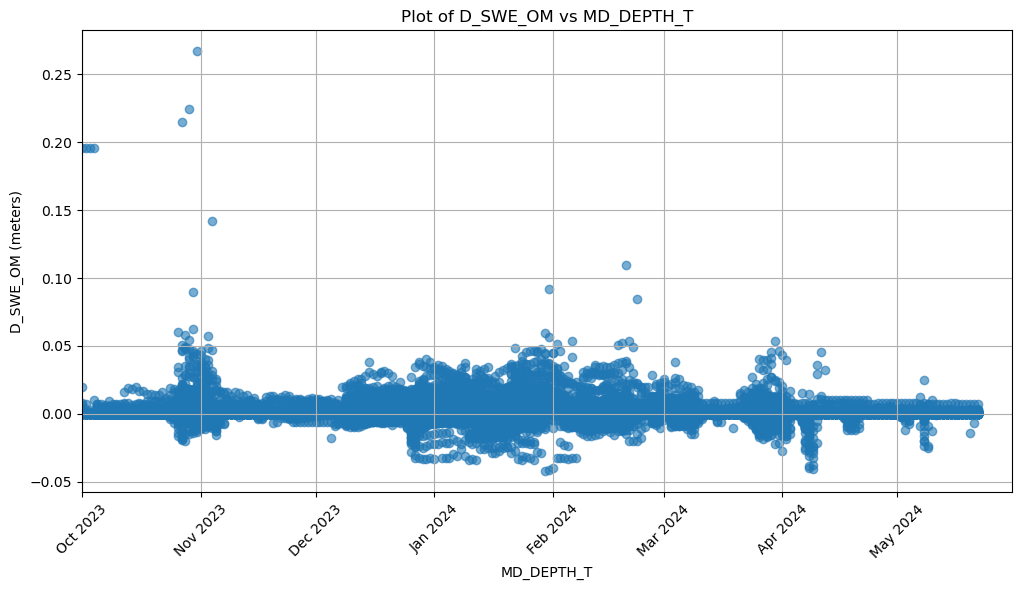

In [6]:
# Convert MD_DEPTH_T to datetime format if not already done
UMRB_stations_all_dates['MD_DEPTH_T'] = pd.to_datetime(UMRB_stations_all_dates['MD_DEPTH_T'])

# Filter data to include only October to May
filtered_data = UMRB_stations_all_dates[UMRB_stations_all_dates['MD_DEPTH_T'].dt.month.isin([10, 11, 12, 1, 2, 3, 4, 5])]

# Plot D_SWE_OM vs MD_DEPTH_T
plt.figure(figsize=(12, 6))  # Optional: Set the figure size
plt.scatter(filtered_data['MD_DEPTH_T'], filtered_data['D_SWE_OM'], alpha=0.6)

# Set the x-axis to show months from October to May and stop after May 2024
start_date = pd.Timestamp(year=filtered_data['MD_DEPTH_T'].dt.year.min(), month=10, day=1)
end_date = pd.Timestamp(year=2024, month=5, day=31)
plt.xlim(start_date, end_date)

# Format the x-axis to show month and year
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Rotate and format the x-axis labels for better readability
plt.xticks(rotation=45)

# Set the title and labels
plt.title('Plot of D_SWE_OM vs MD_DEPTH_T')
plt.xlabel('MD_DEPTH_T')
plt.ylabel('D_SWE_OM (meters)')

# Add grid for better readability
plt.grid(True)

# Show the plot
plt.show()



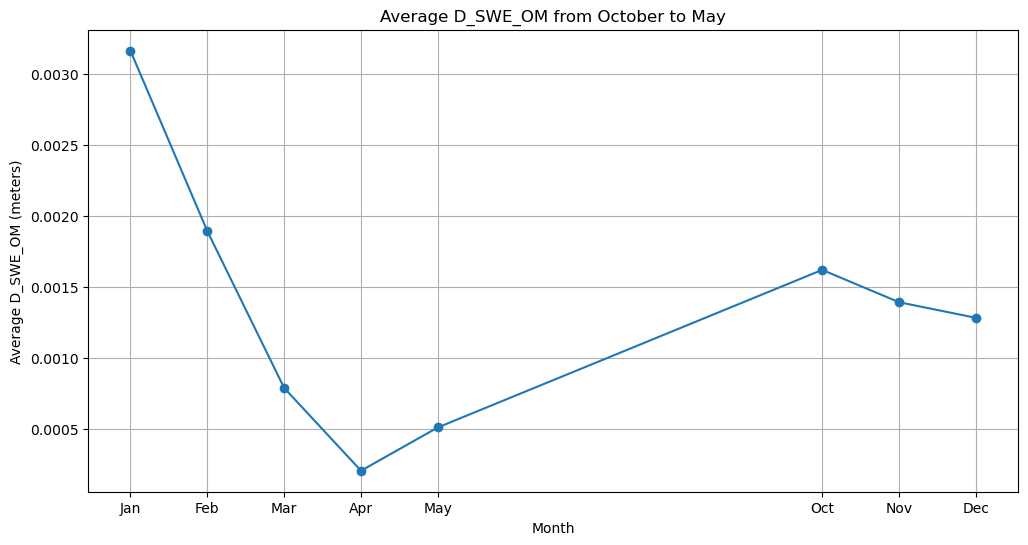

In [7]:
# Step 1: Convert MD_DEPTH_T to datetime format if not already done
UMRB_stations_all_dates['MD_DEPTH_T'] = pd.to_datetime(UMRB_stations_all_dates['MD_DEPTH_T'])

# Step 2: Extract the month from MD_DEPTH_T
UMRB_stations_all_dates['Month'] = UMRB_stations_all_dates['MD_DEPTH_T'].dt.month

# Step 3: Filter data to include only October to May
filtered_data = UMRB_stations_all_dates[UMRB_stations_all_dates['Month'].isin([10, 11, 12, 1, 2, 3, 4, 5])]

# Step 4: Group by month and calculate the average D_SWE_OM
monthly_avg_D_SWE_OM = filtered_data.groupby('Month')['D_SWE_OM'].mean()

# Step 5: Plot the average D_SWE_OM against the months from October to May
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_D_SWE_OM.index, monthly_avg_D_SWE_OM.values, marker='o')

# Set the x-axis to show month names in the order from October to May
months = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']
plt.xticks([10, 11, 12, 1, 2, 3, 4, 5], months)

# Set the title and labels
plt.title('Average D_SWE_OM from October to May')
plt.xlabel('Month')
plt.ylabel('Average D_SWE_OM (meters)')

# Show the plot
plt.grid(True)
plt.show()



Analysis:

Not suprisingly we see some higher averages when looking at the observed vs measured values in the snowery monts of January and February. One thing that did stand out is that we can see that meteorological model seems to be underpredicting the SWE on average for every single month of this season. Hard to make much of this by looking at just one winter but it is something to note none the less.

## Multivariate Regression - For UMRB Stations (All Dates - 10/01/23-5/21/24)

In [8]:
# create dependent and independent value dataframe

URMB_all_date_variables = UMRB_stations_all_dates[['D_SWE_OM','LATITUDE','LONGITUDE','wind_speed', 'min_temp', 'max_temp', 'surf_radiation', 'cummulative_precip', 'STATION_EL']]

# Define the prefix you want to add
prefix = 'Y1_','X1_','X2_','X3_','X4_','X5_','X6_','X7_','X8_'

# Add the prefixes to the column names
URMB_all_date_variables.columns = [prefix + col for prefix, col in zip(prefix, URMB_all_date_variables.columns)]

# Drop rows with NaN values
URMB_all_date_variables = URMB_all_date_variables.dropna()

URMB_all_date_variables

,Y1_D_SWE_OM,X1_LATITUDE,X2_LONGITUDE,X3_wind_speed,X4_min_temp,X5_max_temp,X6_surf_radiation,X7_cummulative_precip,X8_STATION_EL
0,0.034214,46.4880,-103.3160,5.0,260.2,264.4,123.3,48.5,875.0
1,0.046536,46.4880,-103.3160,3.8,261.2,268.1,125.1,48.5,875.0
2,0.047909,46.4880,-103.3160,5.6,264.2,269.7,80.9,48.5,875.0
3,0.041762,46.4880,-103.3160,6.6,253.2,270.7,112.0,48.5,875.0
4,0.041550,46.4880,-103.3160,3.8,254.4,272.8,95.4,48.5,875.0
...,...,...,...,...,...,...,...,...,...
24156,0.000305,46.0135,-99.6876,4.6,282.0,303.6,307.4,166.6,627.0
24157,0.000102,46.0135,-99.6876,7.6,279.8,292.0,306.2,172.5,627.0
24158,0.000102,46.0135,-99.6876,5.3,279.5,293.3,292.8,172.5,627.0
24159,0.000305,46.0135,-99.6876,3.1,280.4,291.6,253.2,175.3,627.0


In [9]:
# Look at correlation between independent parameters for each assimilation

# Create correlation coefficient matrix
UMRB_all_date_corr_coff = URMB_all_date_variables[['X1_LATITUDE','X2_LONGITUDE','X3_wind_speed', 'X4_min_temp', 'X5_max_temp', 'X6_surf_radiation', 'X7_cummulative_precip', 'X8_STATION_EL']].corr()

UMRB_all_date_corr_coff

,X1_LATITUDE,X2_LONGITUDE,X3_wind_speed,X4_min_temp,X5_max_temp,X6_surf_radiation,X7_cummulative_precip,X8_STATION_EL
X1_LATITUDE,1.000000,0.019640,0.076323,-0.050296,-0.107956,-0.082152,-0.022528,-0.593326
X2_LONGITUDE,0.019640,1.000000,0.149136,-0.090903,-0.123629,-0.001969,-0.071437,-0.728332
X3_wind_speed,0.076323,0.149136,1.000000,0.088487,0.043651,0.096012,0.125396,-0.107965
X4_min_temp,-0.050296,-0.090903,0.088487,1.000000,0.884552,0.496196,0.286627,0.091226
X5_max_temp,-0.107956,-0.123629,0.043651,0.884552,1.000000,0.581045,0.261887,0.131590
X6_surf_radiation,-0.082152,-0.001969,0.096012,0.496196,0.581045,1.000000,0.664343,0.058174
X7_cummulative_precip,-0.022528,-0.071437,0.125396,0.286627,0.261887,0.664343,1.000000,0.101198
X8_STATION_EL,-0.593326,-0.728332,-0.107965,0.091226,0.131590,0.058174,0.101198,1.000000


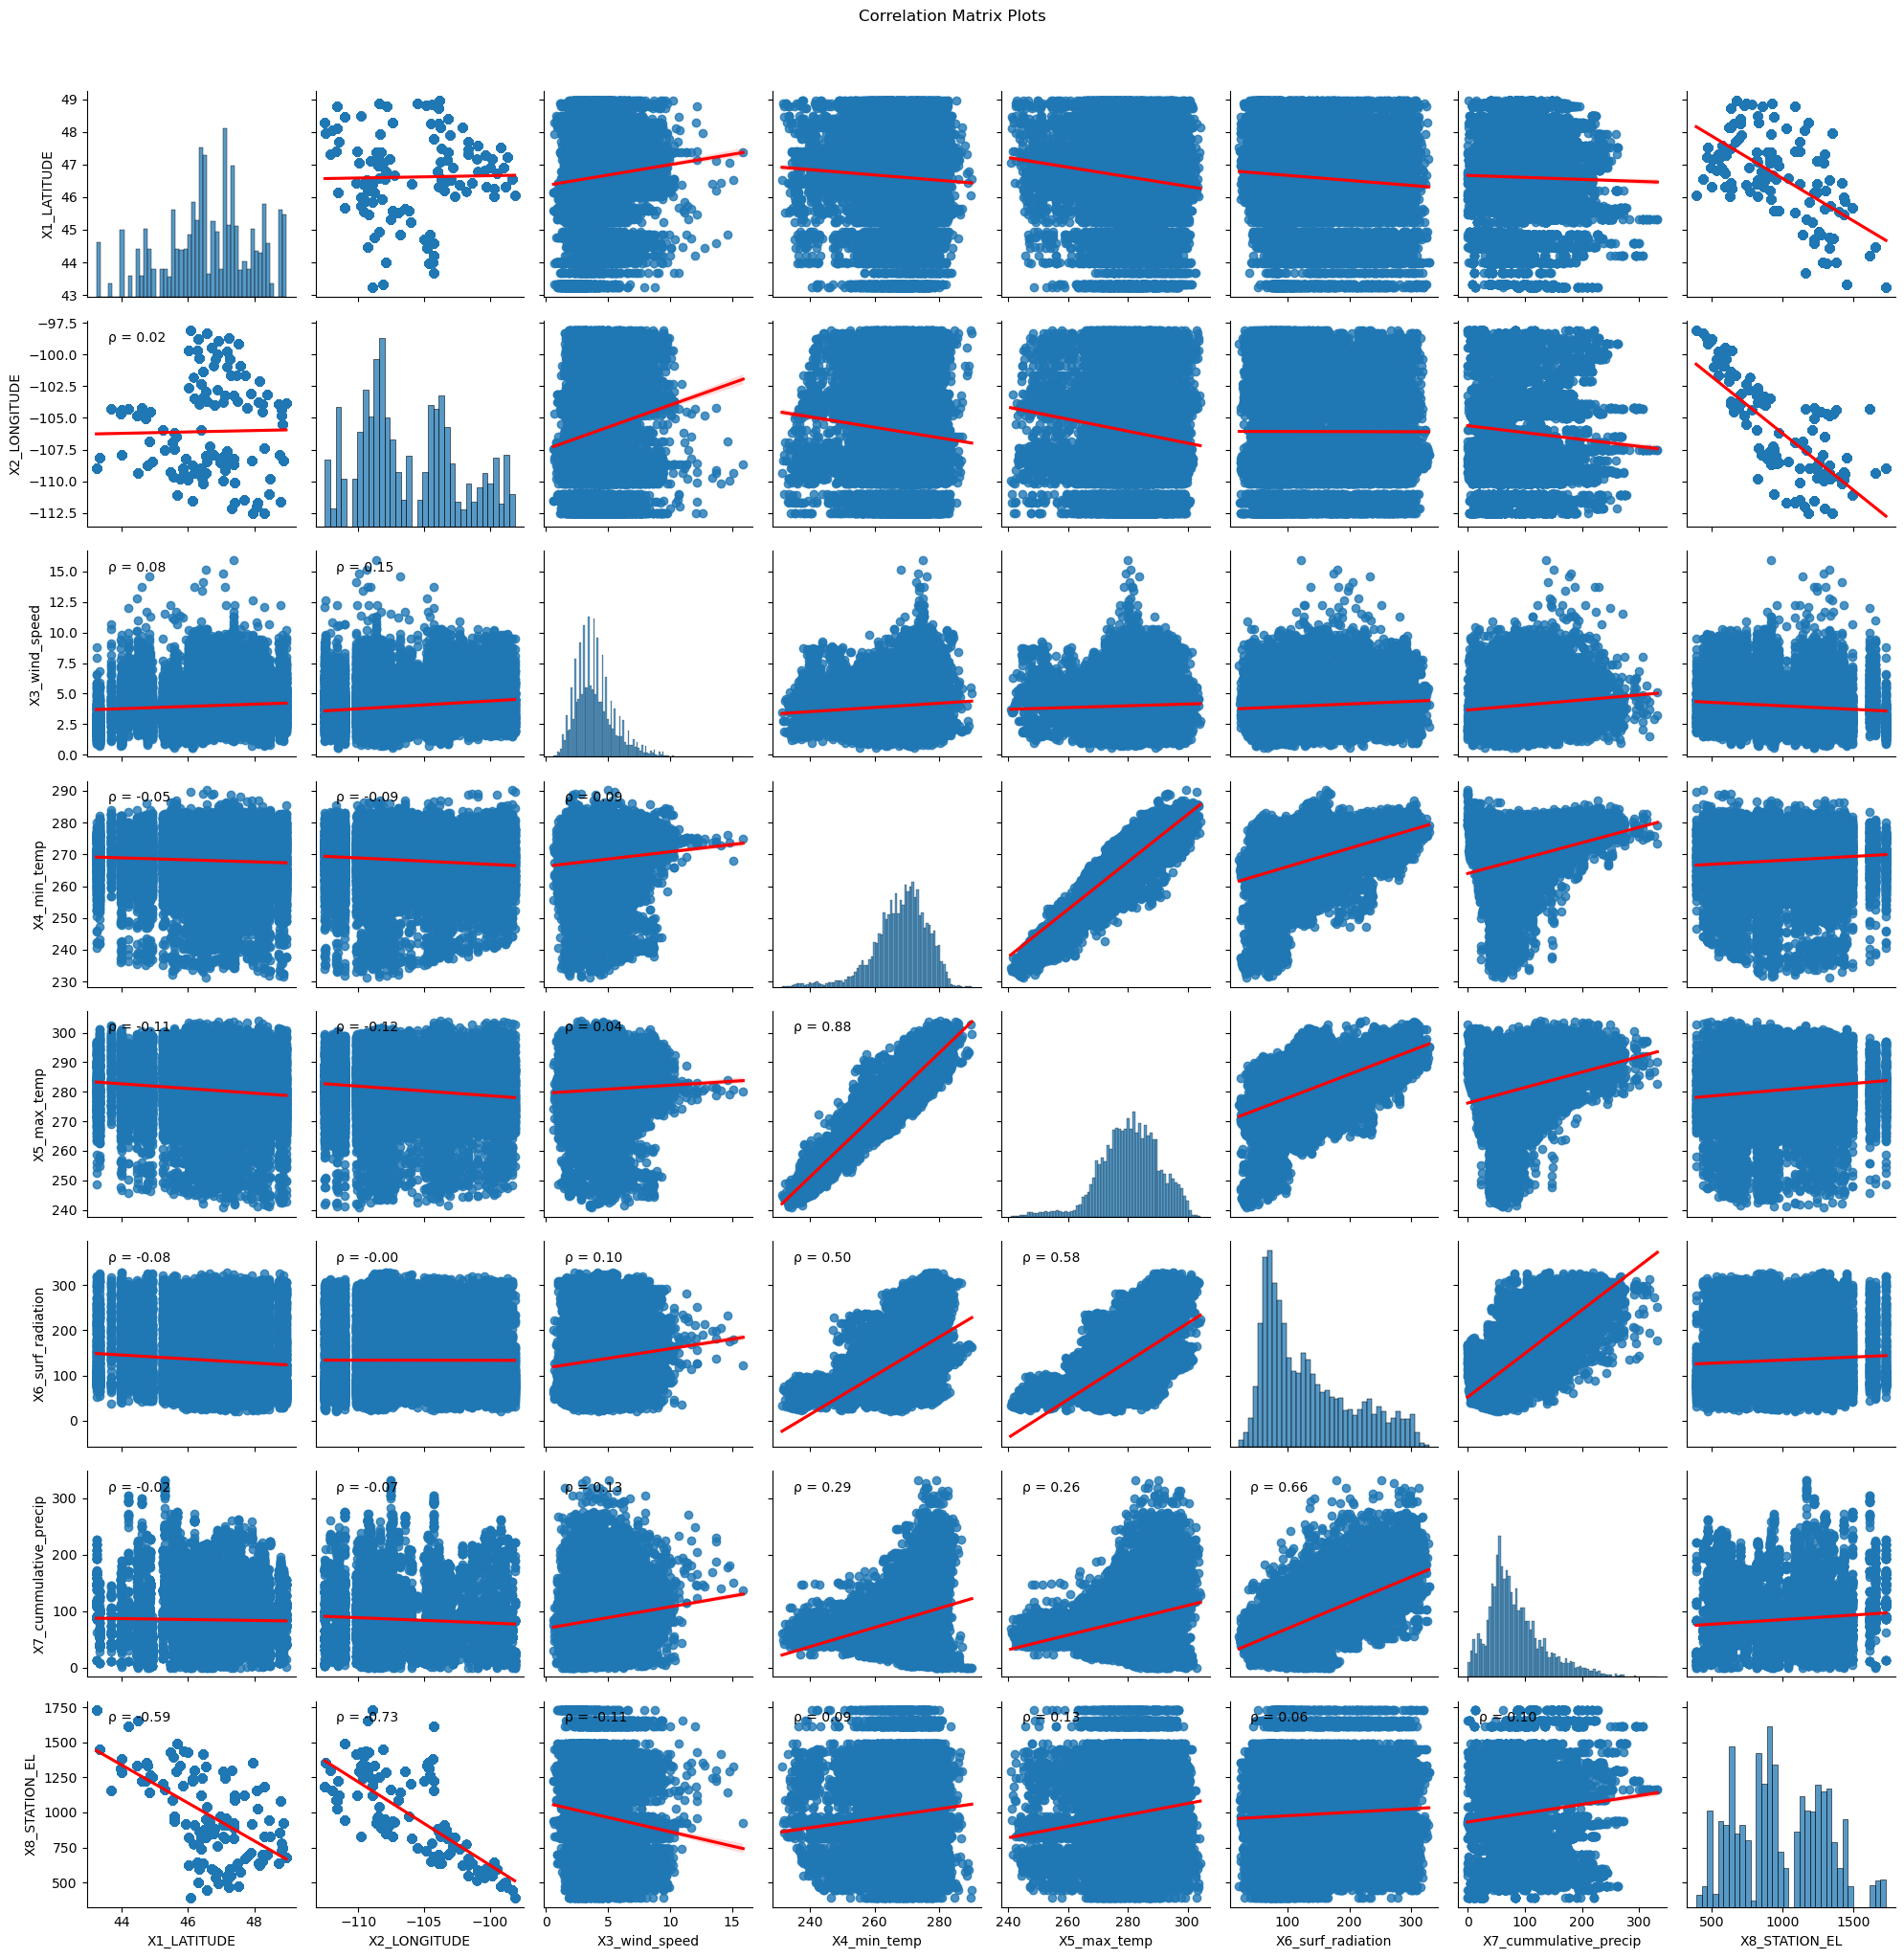

In [10]:
# Define the correlation function
def corrfunc(x, y, ax=None, **kws):
    """Plot the correlation coefficient in the top left-hand corner of a plot."""
    mask = ~np.isnan(x) & ~np.isnan(y)
    r, _ = stats.pearsonr(x[mask], y[mask])
    ax = ax or plt.gca()
    ax.annotate(f'ρ = {r:.2f}', xy=(.1, .9), xycoords=ax.transAxes)

# Create the pairplot
g = sns.pairplot(URMB_all_date_variables[['X1_LATITUDE','X2_LONGITUDE','X3_wind_speed', 'X4_min_temp', 'X5_max_temp', 'X6_surf_radiation', 'X7_cummulative_precip', 'X8_STATION_EL']], kind="reg", plot_kws={'line_kws':{'color':'red'}})

# Apply the correlation function to the lower triangle
g.map_lower(corrfunc)

# Add the title
g.fig.suptitle("Correlation Matrix Plots", y=1.02)  # Adjust y for spacing

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

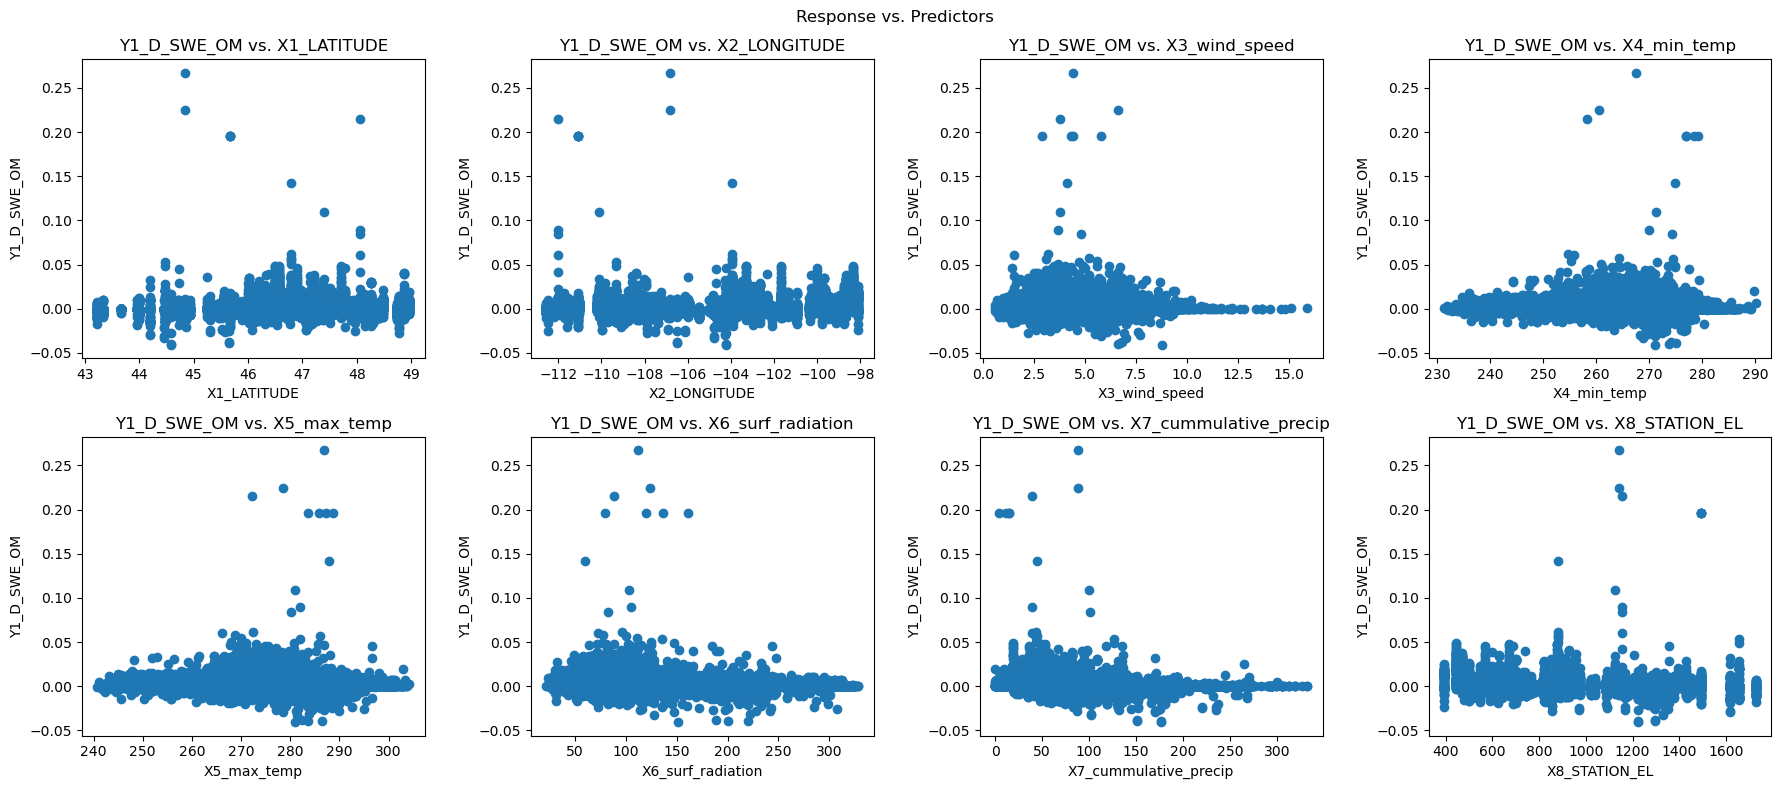

In [11]:
# Assume predictors are labeled as X1_, X2_, ..., X8_
predictors = [col for col in URMB_all_date_variables.columns if col.startswith('X')]

# Find the response variable (Y1_)
response = [col for col in URMB_all_date_variables.columns if col.startswith('Y')][0]

# Create subplots
fig, ax = plt.subplots(2, 4, figsize=(18, 8))

# Loop through the predictors and plot against the response
for i, predictor in enumerate(predictors):
    row = i // 4
    col = i % 4
    ax[row, col].scatter(URMB_all_date_variables[predictor], URMB_all_date_variables[response])
    ax[row, col].set_title(f'{response} vs. {predictor}')
    ax[row, col].set_xlabel(predictor)
    ax[row, col].set_ylabel(response)

# Adjust layout and show plot
plt.suptitle('Response vs. Predictors')
plt.tight_layout()
plt.show()

In [12]:
ols = sm.OLS(URMB_all_date_variables[response], URMB_all_date_variables[predictors])
ols_result = ols.fit()
ols_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            Y1_D_SWE_OM   R-squared (uncentered):                   0.073
Model:                            OLS   Adj. R-squared (uncentered):              0.072
Method:                 Least Squares   F-statistic:                              197.9
Date:                Mon, 22 Jul 2024   Prob (F-statistic):                        0.00
Time:                        11:36:06   Log-Likelihood:                          72619.
No. Observations:               20228   AIC:                                 -1.452e+05
Df Residuals:                   20220   BIC:                                 -1.452e+05
Df Model:                           8                                                  
Covariance Type:            nonrobust                                                  
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
X1_LATITUDE               0.0003   5.85e-05      4.389      0.000       0.000       0.000
X2_LONGITUDE              0.0001    2.8e-05      4.151      0.000    6.14e-05       0.000
X3_wind_speed          1.942e-06   2.98e-05      0.065      0.948   -5.65e-05    6.03e-05
X4_min_temp            4.236e-05   1.22e-05      3.468      0.001    1.84e-05    6.63e-05
X5_max_temp           -2.428e-05   1.14e-05     -2.130      0.033   -4.66e-05   -1.94e-06
X6_surf_radiation     -4.465e-06   1.06e-06     -4.201      0.000   -6.55e-06   -2.38e-06
X7_cummulative_precip   -6.1e-06   1.34e-06     -4.557      0.000   -8.72e-06   -3.48e-06
X8_STATION_EL          -1.72e-06   4.17e-07     -4.126      0.000   -2.54e-06   -9.03e-07
==============================================================================
Omnibus:                    37553.047   Durbin-Watson:                   0.721
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        140165644.029
Skew:                          13.645   Prob(JB):                         0.00
Kurtosis:                     409.888   Cond. No.                     1.52e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 1.52e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
def stepwise_selection(X, y, 
                           initial_list=[], 
                           threshold_in=0.01, 
                           threshold_out = 0.05, 
                           verbose=True):
        """ Perform a forward-backward feature selection 
        based on p-value from statsmodels.api.OLS
        Arguments:
            X - pandas.DataFrame with candidate features
            y - list-like with the target
            initial_list - list of features to start with (column names of X)
            threshold_in - include a feature if its p-value < threshold_in
            threshold_out - exclude a feature if its p-value > threshold_out
            verbose - whether to print the sequence of inclusions and exclusions
        Returns: list of selected features 
        Always set threshold_in < threshold_out to avoid infinite looping.
        See https://en.wikipedia.org/wiki/Stepwise_regression for the details
        """
        included = list(initial_list)
        while True:
            changed=False
            # forward step
            excluded = list(set(X.columns)-set(included))
            new_pval = pd.Series(index=excluded)
            for new_column in excluded:
                model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
                new_pval[new_column] = model.pvalues[new_column]
            best_pval = new_pval.min()
            if best_pval < threshold_in:
                best_feature = new_pval.idxmin()
                included.append(best_feature)
                changed=True
                if verbose:
                    print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

            # backward step
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
            # use all coefs except intercept
            pvalues = model.pvalues.iloc[1:]
            worst_pval = pvalues.max() # null if pvalues is empty
            if worst_pval > threshold_out:
                changed=True
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                if verbose:
                    print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
            if not changed:
                break
        return included

In [14]:
result = stepwise_selection(URMB_all_date_variables[predictors], pd.Series(URMB_all_date_variables[response]))

print('resulting features:')
print(result)

Add  X2_LONGITUDE                   with p-value 8.64966e-138
Add  X6_surf_radiation              with p-value 1.30431e-33
Add  X8_STATION_EL                  with p-value 5.62496e-15
Add  X5_max_temp                    with p-value 3.24679e-08
Add  X7_cummulative_precip          with p-value 8.80448e-07
Drop X6_surf_radiation              with p-value 0.179787
Add  X1_LATITUDE                    with p-value 0.00309055
resulting features:
['X2_LONGITUDE', 'X8_STATION_EL', 'X5_max_temp', 'X7_cummulative_precip', 'X1_LATITUDE']


# Below code downloads data from URL

In [ ]:
import os
import requests
from urllib.parse import urljoin

# Define the base URL and destination directory
base_url = "https://www.nohrsc.noaa.gov/pub/staff/fall/UMRB/snodas_assims_2023_2024/snodas_assim_20231228_with_umrb/"
destination_path = r"C:\Repos\umrb-snodas\Test_Runs\snodas_assim_20231228_with_umrb_updated"

# Ensure the destination directory exists
os.makedirs(destination_path, exist_ok=True)

# List of file names to download
file_names = ['snodas_assim_points_2023122812_central.png', 'snodas_idw_cv_2023122812_central_3_50_2.0_2.0_200.png', 'snodas_idw_nudging_2023122812_central_3_50_2.0_2.0_200.png', 'ssm1054_2023122812.nc', 'ssm1054_2023122812_central.nc', 'ssm1054_2023122812_east.nc', 'ssm1054_2023122812_west.nc', 'ssm1054_md_based_2023122712_2023122812_central.dbf', 'ssm1054_md_based_2023122712_2023122812_central.prj', 'ssm1054_md_based_2023122712_2023122812_central.shp', 'ssm1054_md_based_2023122712_2023122812_central.shx', 'ssm1054_snodas_idw_test_2023122812_central.nc', 'ssm_process_region_2023122712_2023122812_swe_central.nc']

# Function to download a file
def download_file(url, destination):
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()  # Ensure the request was successful
        file_path = os.path.join(destination, os.path.basename(url))
        with open(file_path, 'wb') as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
        print(f"Downloaded: {file_path}")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading {url}: {e}")

# Download each file
for file_name in file_names:
    file_url = urljoin(base_url, file_name)
    download_file(file_url, destination_path)

print("All files have been downloaded.")

